In [ ]:
!pip install deepxde

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


3D Helmholtz Equation - Physics-Informed Neural Network Solver

Problem Parameters:
  Domain: ((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0))
  Grid points (evaluation): 21 × 21 × 21 = 9261
  Grid spacing: Δx = 0.1000
  PDE: ∇²u + k²u = 2.0
  BC: u = 0 on boundary (hard constraint)
  Wave number k²: 1

Training PINN...
Compiling model...
'compile' took 5.223749 s

Training model...

Step      Train loss    Test loss     Test metric
0         [4.64e+00]    [4.79e+00]    []  
1000      [2.22e-01]    [4.75e-02]    []  
2000      [1.59e-01]    [2.79e-02]    []  
3000      [9.81e-02]    [9.69e-03]    []  
4000      [6.08e-02]    [5.09e-03]    []  
5000      [4.60e-02]    [5.41e-03]    []  
6000      [3.62e-02]    [5.54e-03]    []  
7000      [3.18e-02]    [6.34e-03]    []  
8000      [2.15e-02]    [3.87e-03]    []  
9000      [1.67e-02]    [3.18e-03]    []  
10000     [1.36e-02]    [2.66e-03]    []  

Best model at step 10000:
  train loss: 1.36e-02
  test loss: 2.66e-03
  test metric: []

'train' 

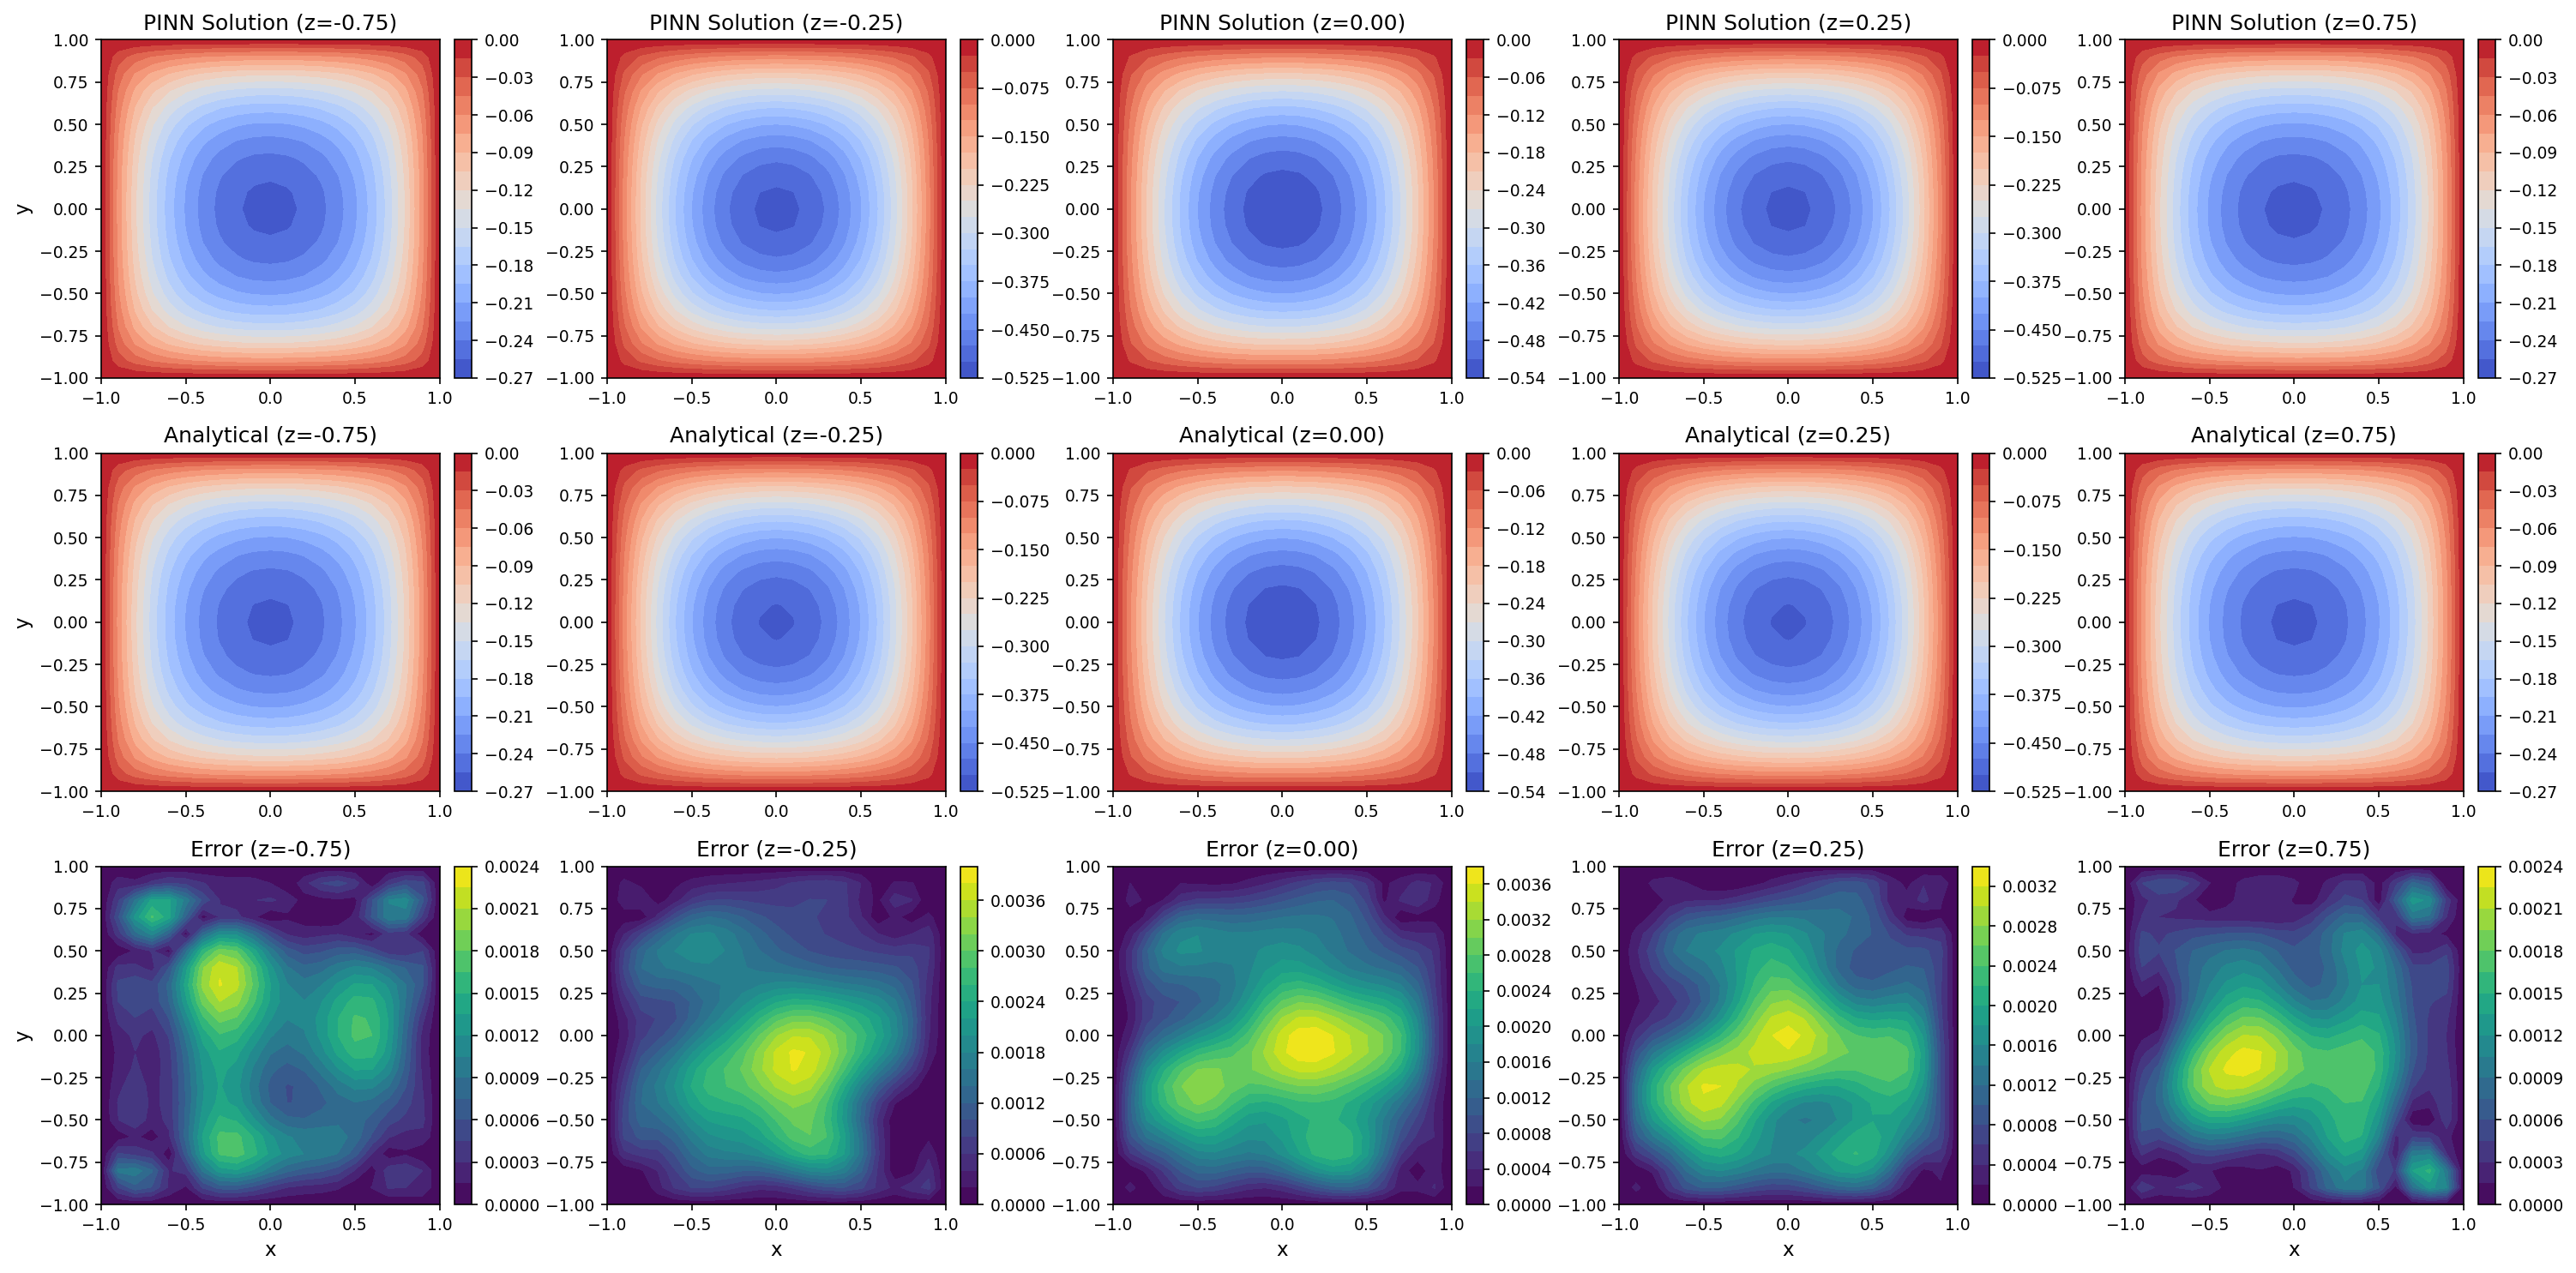


Visualization complete!


In [ ]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import numpy as np
import matplotlib.pyplot as plt
import deepxde as dde
from typing import Dict, Tuple, Optional, List

np.random.seed(42)
dde.config.set_random_seed(42)

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
})
plt.rcParams['text.usetex'] = False

cmap_diverging = 'coolwarm'  # for solution
cmap_uncertainty = 'viridis'  # for error/uncertainty

# ----------------------------
# Problem parameters
# ----------------------------
DOMAIN = ((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0))
GRID_POINTS = (21, 21, 21)
G_PRIME = 1.0
G_DOUBLE_PRIME = 0.0
RHO = 1.0
OMEGA = 1.0
SOURCE_VALUE = 2.0


def compute_k_squared(G_prime=G_PRIME, G_double_prime=G_DOUBLE_PRIME, rho=RHO, omega=OMEGA):
    k_sq = (rho * omega ** 2) / (G_prime + 1j * G_double_prime)
    return np.real(k_sq)


# ----------------------------
# PINN definition
# ----------------------------

def make_pinn_solver(
    k_squared=compute_k_squared(),
    num_domain=21 ** 3,
    num_boundary=6 * (21 ** 2),
    num_test=21 ** 3,
    layers=None,
    activation="tanh",
    learning_rate=1e-3,
    iterations=10000,
    display_every=1000,
):
    """
    Solve (u_xx + u_yy + u_zz + k^2 u) = 2 on [-1,1]^3 with u=0 on boundary.
    Training configuration is fixed for reproducibility.
    """
    # Geometry
    geom = dde.geometry.Cuboid(xmin=[-1.0, -1.0, -1.0], xmax=[1.0, 1.0, 1.0])

    # PDE residual: u_xx + u_yy + u_zz + k^2 u - 2 = 0
    def pde(x, y):
        u_xx = dde.grad.hessian(y, x, i=0, j=0)
        u_yy = dde.grad.hessian(y, x, i=1, j=1)
        u_zz = dde.grad.hessian(y, x, i=2, j=2)
        f = SOURCE_VALUE + 0.0 * x[:, 0:1]
        return u_xx + u_yy + u_zz + k_squared * y - f

    # Hard Dirichlet BC via output transform: (1-x^2)(1-y^2)(1-z^2) * NN(x,y,z)
    def output_transform(x, y):
        factor = (1.0 - x[:, 0:1] ** 2) * (1.0 - x[:, 1:2] ** 2) * (1.0 - x[:, 2:3] ** 2)
        return factor * y

    data = dde.data.PDE(
        geom,
        pde,
        bcs=[],
        num_domain=num_domain,
        num_boundary=num_boundary,
        num_test=num_test,
    )

    if layers is None:
        layers = [3, 32, 32, 32, 1]

    net = dde.nn.FNN(layers, activation, "Glorot uniform")
    net.apply_output_transform(output_transform)

    model = dde.Model(data, net)
    model.compile("adam", lr=learning_rate)
    losshistory, train_state = model.train(iterations=iterations, display_every=display_every)

    # Optional: L-BFGS refinement (uncomment if memory allows)
    # dde.optimizers.set_LBFGS_options(maxiter=5000)
    # model.compile("L-BFGS-B")
    # losshistory, train_state = model.train()

    return model, (losshistory, train_state)


# ----------------------------
# Analytical solution
# ----------------------------

def analytical_constant_source_3d(X, Y, Z, k_squared=1.0, M=51, N=51, P=51):
    """
    Approximate analytic solution of (Δ + k^2) u = 2 on (-1,1)^3,
    u = 0 on the boundary, using a truncated sine series.
    """
    # Map to [0,1]
    xi = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    zeta = (Z + 1.0) / 2.0

    dtype = complex if np.iscomplexobj(k_squared) else float
    u = np.zeros_like(X, dtype=dtype)

    C = 2.0
    for m in range(1, M, 2):
        for n in range(1, N, 2):
            for p in range(1, P, 2):
                lam = (np.pi * m / 2) ** 2 + (np.pi * n / 2) ** 2 + (np.pi * p / 2) ** 2
                denom = -lam + k_squared
                f_coeff = C * (4.0 / np.pi) ** 3 / (m * n * p)
                u_coeff = f_coeff / denom
                u += u_coeff * np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta) * np.sin(np.pi * p * zeta)
    return u


# -----------
# Evaluation
# -----------

def eval_on_grid(model, k_squared=1.0, n_points=GRID_POINTS, series_terms=(51, 51, 51)):
    nx, ny, nz = n_points
    x = np.linspace(-1, 1, nx)
    y = np.linspace(-1, 1, ny)
    z = np.linspace(-1, 1, nz)
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    pts = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)
    u_pred = model.predict(pts).reshape(nx, ny, nz)

    u_true = analytical_constant_source_3d(X, Y, Z, k_squared=k_squared, M=series_terms[0], N=series_terms[1], P=series_terms[2])
    u_true_real = np.real(u_true)

    diff = u_true_real - u_pred

    metrics = {
        "mse": float(np.mean(np.abs(diff) ** 2)),
        "rmse": float(np.sqrt(np.mean(np.abs(diff) ** 2))),
        "mae": float(np.mean(np.abs(diff))),
        "max_error": float(np.max(np.abs(diff))),
        "relative_l2": float(np.linalg.norm(diff) / np.linalg.norm(u_true_real)),
    }

    return metrics, (X, Y, Z, u_pred, u_true_real)


# ---------------
# Visualization
# ---------------

def plot_solution_slices(
    model,
    z_values: List[float],
    x: Optional[np.ndarray] = None,
    y: Optional[np.ndarray] = None,
    k_squared: float = 1.0,
    save_path: Optional[str] = None,
    show_plot: bool = True,
):
    if x is None:
        x = np.linspace(-1, 1, GRID_POINTS[0])
    if y is None:
        y = np.linspace(-1, 1, GRID_POINTS[1])

    X_slice, Y_slice = np.meshgrid(x, y, indexing="ij")
    num_slices = len(z_values)
    if num_slices == 0:
        return

    fig, axes = plt.subplots(3, num_slices, figsize=(4 * num_slices, 10), squeeze=False)

    for k, z_val in enumerate(z_values):
        Z_plane = np.full_like(X_slice, z_val)
        pts = np.stack([X_slice.flatten(), Y_slice.flatten(), Z_plane.flatten()], axis=1)
        u_pinn = model.predict(pts).reshape(X_slice.shape)

        u_ana = analytical_constant_source_3d(X_slice, Y_slice, Z_plane, k_squared=k_squared, M=51, N=51, P=51)
        u_ana = np.real(u_ana)

        err_slice = np.abs(u_pinn - u_ana)

        # Row 1: PINN Solution
        ax = axes[0, k]
        im1 = ax.contourf(X_slice, Y_slice, u_pinn, levels=20, cmap=cmap_diverging)
        ax.set_title(f"PINN Solution (z={z_val:.2f})")
        ax.set_aspect('equal')
        if k == 0:
            ax.set_ylabel("y")
        fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

        # Row 2: Analytical Solution
        ax = axes[1, k]
        im2 = ax.contourf(X_slice, Y_slice, u_ana, levels=20, cmap=cmap_diverging)
        ax.set_title(f"Analytical (z={z_val:.2f})")
        ax.set_aspect('equal')
        if k == 0:
            ax.set_ylabel("y")
        fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

        # Row 3: Error
        ax = axes[2, k]
        im3 = ax.contourf(X_slice, Y_slice, err_slice, levels=20, cmap=cmap_uncertainty)
        ax.set_title(f"Error (z={z_val:.2f})")
        ax.set_aspect('equal')
        ax.set_xlabel("x")
        if k == 0:
            ax.set_ylabel("y")
        fig.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show_plot:
        plt.show()


# ----------------------------
# Main
# ----------------------------

def main():
    print("=" * 70)
    print("3D Helmholtz Equation - Physics-Informed Neural Network Solver")
    print("=" * 70)

    k2 = compute_k_squared()
    nx, ny, nz = GRID_POINTS
    dx = (DOMAIN[0][1] - DOMAIN[0][0]) / (nx - 1)

    print("\nProblem Parameters:")
    print(f"  Domain: {DOMAIN}")
    print(f"  Grid points (evaluation): {nx} × {ny} × {nz} = {nx * ny * nz}")
    print(f"  Grid spacing: Δx = {dx:.4f}")
    print(f"  PDE: ∇²u + k²u = {SOURCE_VALUE}")
    print(f"  BC: u = 0 on boundary (hard constraint)")
    print(f"  Wave number k²: {k2:.6g}")

    print("\nTraining PINN...")
    model, (losshistory, train_state) = make_pinn_solver(
        k_squared=k2,
        num_domain=2000,
        num_boundary=400,
        num_test=2000,
    )
    print("Training completed!")

    print("\nEvaluation Metrics (on 21×21×21 grid):")
    print("-" * 40)
    metrics, (X, Y, Z, u_pinn, u_true) = eval_on_grid(model, k_squared=k2, n_points=GRID_POINTS, series_terms=(51, 51, 51))
    for name, value in metrics.items():
        print(f"  {name.upper():15s}: {value:.6e}")

    print(f"\n  Solution range (PINN): [{np.min(u_pinn):.4f}, {np.max(u_pinn):.4f}]")

    print("\nGenerating visualization slices...")
    z_slices = [-0.75, -0.25, 0.0, 0.25, 0.75]
    plot_solution_slices(model, z_slices, k_squared=k2, save_path=None, show_plot=True)

    print("\n" + "=" * 70)
    print("Visualization complete!")
    print("=" * 70)

    return model, metrics


if __name__ == "__main__":
    model, metrics = main()